In [ ]:
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM, GitProcessor, GitForCausalLM, Florence2ForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Florence-2-base ---

FLORENCE_ID = "florence-community/Florence-2-base"
florence_processor = AutoProcessor.from_pretrained(FLORENCE_ID)
florence_model = Florence2ForConditionalGeneration.from_pretrained(
    FLORENCE_ID,
    dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)
florence_model.eval()

# --- GIT-base ---
GIT_ID = "microsoft/git-base"
git_processor = GitProcessor.from_pretrained(GIT_ID)
git_model = GitForCausalLM.from_pretrained(GIT_ID).to(device)
git_model.eval()

print("both models were uploaded successfully.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  463MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/665 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/292 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  707MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/305 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

both models were uploaded successfully.


In [ ]:
def caption_florence(image, prompt="<MORE_DETAILED_CAPTION>", max_tokens=60):
    inputs = florence_processor(text=prompt, images=image, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    pixel_values = inputs["pixel_values"].to(
        device, dtype=torch.float16 if device == "cuda" else torch.float32
    )
    with torch.no_grad():
        generated_ids = florence_model.generate(
            input_ids=input_ids,
            pixel_values=pixel_values,
            max_new_tokens=max_tokens,
            num_beams=3,
            do_sample=False
        )
    generated_text = florence_processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    return florence_processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )[prompt]


def caption_git(image, max_tokens=60):
    pixel_values = git_processor(images=image, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        generated_ids = git_model.generate(
            pixel_values=pixel_values,
            max_length=max_tokens
        )
    return git_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

Saving Screenshot 2026-09-04 122852.png to Screenshot 2026-09-04 122852.png


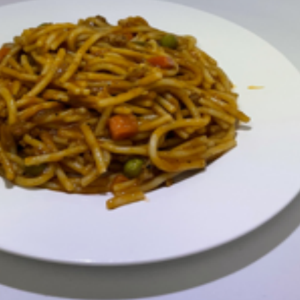

Florence-2-base (zero-shot):
The image shows a plate of spaghetti on a white plate. The spaghetti is long and thin, and it appears to be cooked in a tomato-based sauce. There are small pieces of carrots and peas scattered throughout the dish. The sauce is a reddish-brown color and looks like it

GIT-base (zero-shot):
a plate of noodles


In [ ]:
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

florence_result = caption_florence(image)
git_result = caption_git(image)

print("Florence-2-base (zero-shot):")
print(florence_result)
print("\nGIT-base (zero-shot):")
print(git_result)

Saving AR-JF-27072-Mexican-Rice-ddmfs-2x1-831a9a4a83074cdf8c9150c361c82281.jpg to AR-JF-27072-Mexican-Rice-ddmfs-2x1-831a9a4a83074cdf8c9150c361c82281.jpg


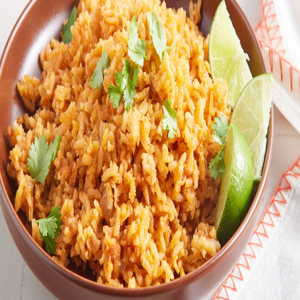

Florence-2-base (zero-shot):
The image shows a bowl of rice dish. The rice appears to be cooked and has a golden brown color. It is garnished with fresh cilantro leaves. There are two lime wedges on the side of the bowl, one on each side. The bowl is sitting on a white table

GIT-base (zero-shot):
a traditional dish of rice


In [ ]:
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

florence_result = caption_florence(image)
git_result = caption_git(image)

print("Florence-2-base (zero-shot):")
print(florence_result)
print("\nGIT-base (zero-shot):")
print(git_result)

Saving download (5).jfif to download (5).jfif


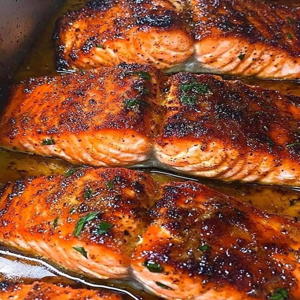

Florence-2-base (zero-shot):
The image shows four pieces of salmon fillets in a baking dish. The salmon is cooked to a golden brown color and appears to be seasoned with herbs and spices. The fillets are arranged in a single layer in the dish, with each piece overlapping the one below it. The dish is

GIT-base (zero-shot):
this recipe is a recipe for a recipe.


In [ ]:
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

florence_result = caption_florence(image)
git_result = caption_git(image)

print("Florence-2-base (zero-shot):")
print(florence_result)
print("\nGIT-base (zero-shot):")
print(git_result)

Saving 77968bc1050eca57b08c1b385621c8ce.jpg to 77968bc1050eca57b08c1b385621c8ce.jpg


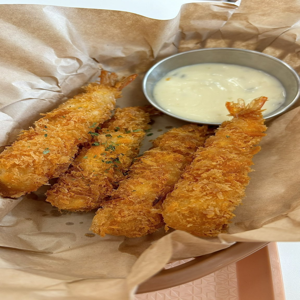

Florence-2-base (zero-shot):
The image shows a basket of fried shrimp with a small bowl of dipping sauce on the side. The shrimp are golden brown and appear to be crispy on the outside. The dipping sauce is a creamy white color and is drizzled over the top of the shrimp. The basket is made of

GIT-base (zero-shot):
fried chicken


In [ ]:
from google.colab import files
from IPython.display import display

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

display(image.resize((300, 300)))

florence_result = caption_florence(image)
git_result = caption_git(image)

print("Florence-2-base (zero-shot):")
print(florence_result)
print("\nGIT-base (zero-shot):")
print(git_result)